# Bank Marketing Campaign Analysis

**Dataset:** UCI Machine Learning Repository - Bank Marketing (ID 222)  
**Source:** [https://archive.ics.uci.edu/dataset/222/bank+marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing)

This project's purpose is to analyzes direct marketing campaign records from a Portuguese bank to explore how contact history, timing, and client attributes relate to term-deposit conversion. Uses 45,211 records across 16 features; target variable `y` flags whether a client subscribed.

## 1. Import Libraries

In [33]:
import os 
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Avoid subprocess warnings
warnings.filterwarnings('ignore', category=UserWarning)
os.environ['PYTHONWARNINGS'] = 'ignore'

## 2. Load Dataset

Fetches the dataset directly from the `ucimlrepo` for full reproducibility, then merges features and target into one working DataFrame.

In [17]:
from ucimlrepo import fetch_ucirepo

# Fetch dataset by UCI ID
bank_marketing = fetch_ucirepo(id=222)

# Separate features and target
X_raw = bank_marketing.data.features
y_raw = bank_marketing.data.targets

# Combine into one working DataFrame
df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (45211, 17)

Column types:
age             int64
job            object
marital        object
education      object
default        object
balance         int64
housing        object
loan           object
contact        object
day_of_week     int64
month          object
duration        int64
campaign        int64
pdays           int64
previous        int64
poutcome       object
y              object
dtype: object

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 3. Exploratory Data Analysis

### 3.1 Age Distribution

Plots the age spread across all contacted clients to understand the demographic range.

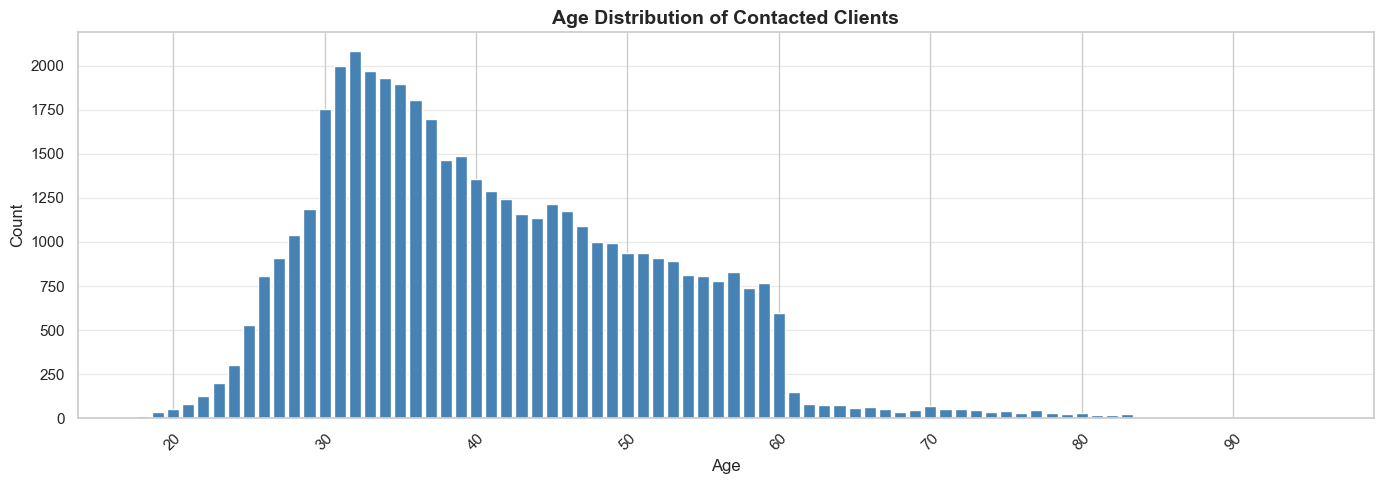

In [18]:
# Plot age distribution across all clients
age_counts = df['age'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Age Distribution of Contacted Clients', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.2 Job Category Distribution

Breaks down clients by occupation to see which job segments dominate the campaign data.

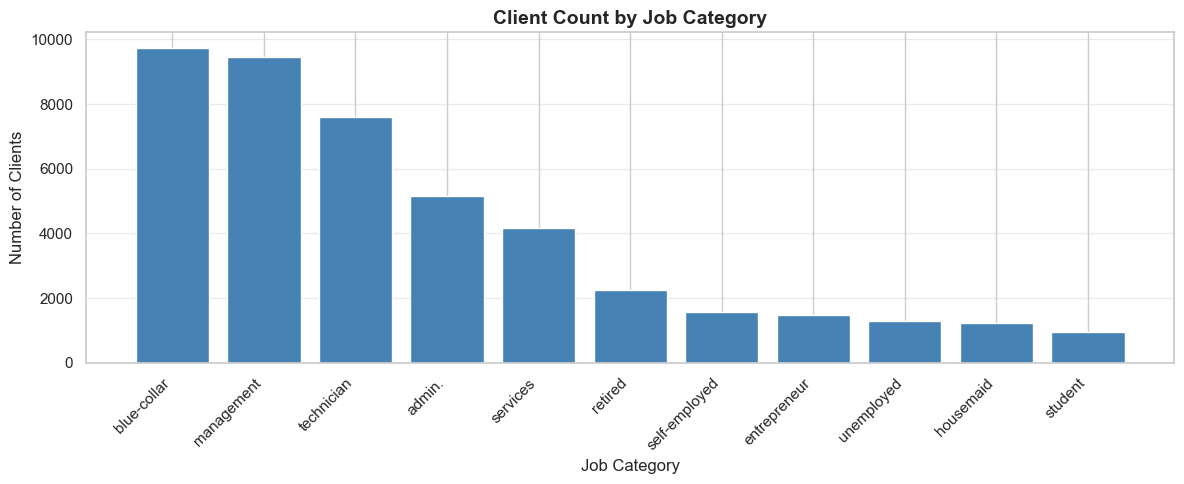

In [19]:
# Plot client count by job category
job_counts = df['job'].value_counts()

plt.figure(figsize=(12, 5))
bars = plt.bar(job_counts.index, job_counts.values, color='steelblue', edgecolor='white')
plt.xlabel('Job Category', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.title('Client Count by Job Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### 3.3 Housing Loan Distribution

Shows the housing loan split across clients as a proxy for financial commitment level.

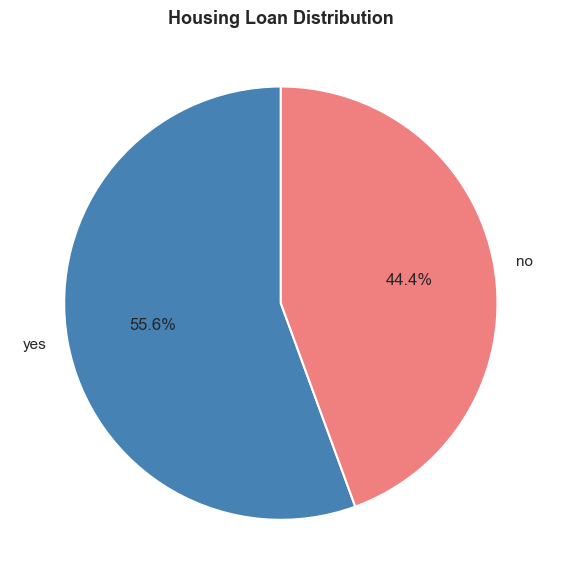

In [20]:
# Plot housing loan status distribution
housing_counts = df['housing'].value_counts()
housing_pct = housing_counts / len(df) * 100

plt.figure(figsize=(6, 6))
plt.pie(
    housing_pct,
    labels=housing_pct.index,
    autopct='%.1f%%',
    colors=['steelblue', 'lightcoral'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Housing Loan Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Marital Status Distribution

Reviews marital status proportions to assess its potential as a targeting signal.

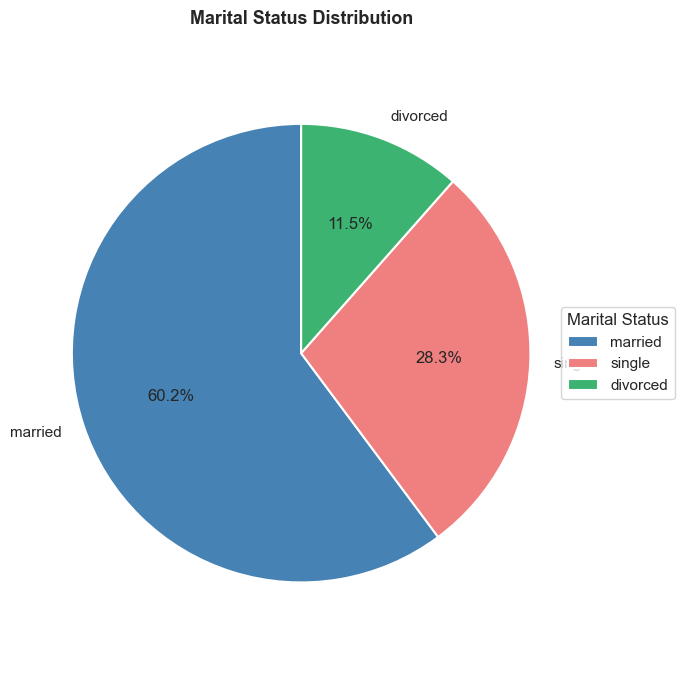

In [21]:
# Plot marital status distribution
marital_counts = df['marital'].value_counts()
marital_pct = marital_counts / len(df) * 100

plt.figure(figsize=(7, 7))
plt.pie(
    marital_pct,
    labels=marital_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'lightcoral', 'mediumseagreen'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Marital Status Distribution', fontsize=13, fontweight='bold')
plt.axis('equal')
plt.legend(title='Marital Status', loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
plt.tight_layout()
plt.show()

### 3.5 Target Class Balance

Checks subscription rate before modeling. The dataset is heavily imbalanced (~88% no, ~12% yes), so class weighting is applied during training to correct for this.

Subscription counts:
y
no     39922
yes     5289

Subscription percentages:
y
no     88.3
yes    11.7


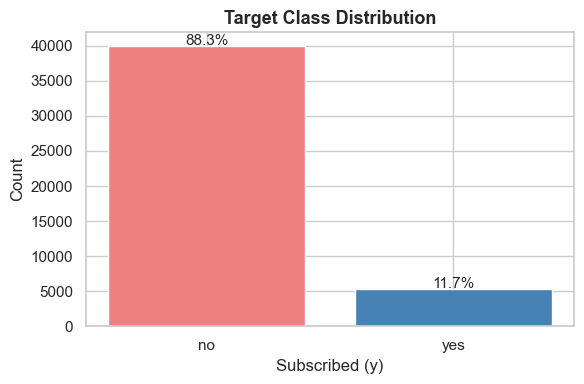

In [22]:
# Inspect target class balance
target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

print("Subscription counts:")
print(target_counts.to_string())
print("\nSubscription percentages:")
print(target_pct.round(2).to_string())

plt.figure(figsize=(6, 4))
bars = plt.bar(target_counts.index, target_counts.values,
               color=['lightcoral', 'steelblue'], edgecolor='white')
for bar, pct in zip(bars, target_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 200,
             f'{pct:.1f}%', ha='center', fontsize=11)
plt.xlabel('Subscribed (y)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Target Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Subscription Rate by Key Campaign Features

Compares conversion rates across contact month, previous campaign outcome, and contact type to surface actionable targeting patterns.

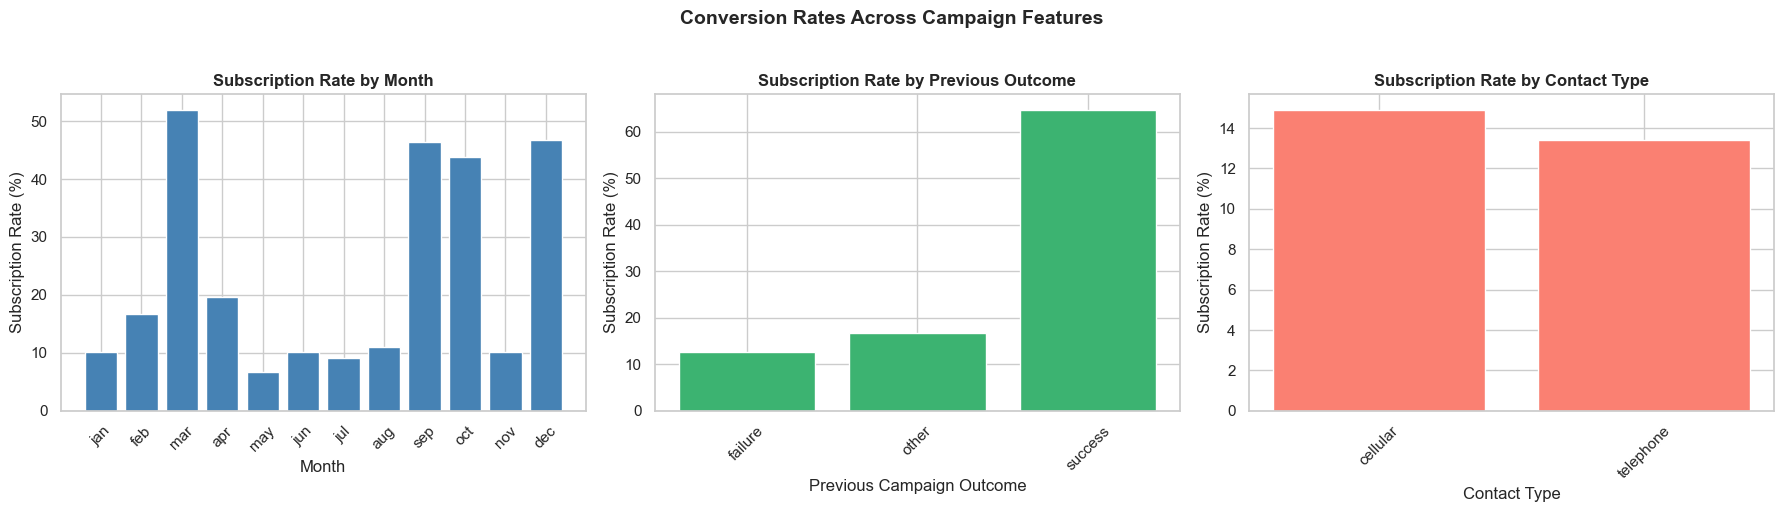

In [23]:
# Compute subscription rate by month, poutcome, and contact type
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Subscription rate by month
month_rate = df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean() * 100)
month_rate = month_rate.reindex([m for m in month_order if m in month_rate.index])
axes[0].bar(month_rate.index, month_rate.values, color='steelblue', edgecolor='white')
axes[0].set_title('Subscription Rate by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Subscription rate by previous campaign outcome
pout_rate = df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean() * 100)
axes[1].bar(pout_rate.index, pout_rate.values, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Subscription Rate by Previous Outcome', fontweight='bold')
axes[1].set_xlabel('Previous Campaign Outcome')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

# Subscription rate by contact type
contact_rate = df.groupby('contact')['y'].apply(lambda x: (x == 'yes').mean() * 100)
axes[2].bar(contact_rate.index, contact_rate.values, color='salmon', edgecolor='white')
axes[2].set_title('Subscription Rate by Contact Type', fontweight='bold')
axes[2].set_xlabel('Contact Type')
axes[2].set_ylabel('Subscription Rate (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Conversion Rates Across Campaign Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering and Encoding

Applies one-hot encoding to nominal categoricals and direct 0/1 mapping to binary fields. Excludes `duration` from modeling as it is a post-contact attribute not available before a call is placed.

In [24]:
# Encode binary features as 0/1
binary_map = {'yes': 1, 'no': 0}
df['default'] = df['default'].map(binary_map)
df['housing'] = df['housing'].map(binary_map)
df['loan'] = df['loan'].map(binary_map)
df['y'] = df['y'].map(binary_map)

# Apply one-hot encoding to nominal categorical features
nominal_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("\nEncoded column list:")
print(list(df_encoded.columns))

Shape after encoding: (45211, 39)

Encoded column list:
['age', 'default', 'balance', 'housing', 'loan', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'contact_telephone', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success']


## 5. Correlation Analysis

### 5.1 Feature Correlation with Target

Ranks features by their linear correlation with `y`. `duration` is included here for reference only and excluded from the model.

In [25]:
# Compute and display feature correlations with target
correlation_matrix = df_encoded.corr(numeric_only=True)
correlation_with_y = correlation_matrix['y'].drop('y').sort_values(key=abs, ascending=False)

print("Top features by absolute correlation with target (y):")
print(correlation_with_y.head(15).round(4).to_string())

Top features by absolute correlation with target (y):
duration            0.3945
poutcome_success    0.3068
housing            -0.1392
month_mar           0.1295
month_oct           0.1285
month_sep           0.1232
pdays               0.1036
month_may          -0.1025
previous            0.0932
job_retired         0.0792
job_student         0.0769
month_dec           0.0752
campaign           -0.0732
job_blue-collar    -0.0721
loan               -0.0682


### 5.2 Correlation Bar Chart

Visualizes the top 15 feature correlations with the target for quick interpretation.

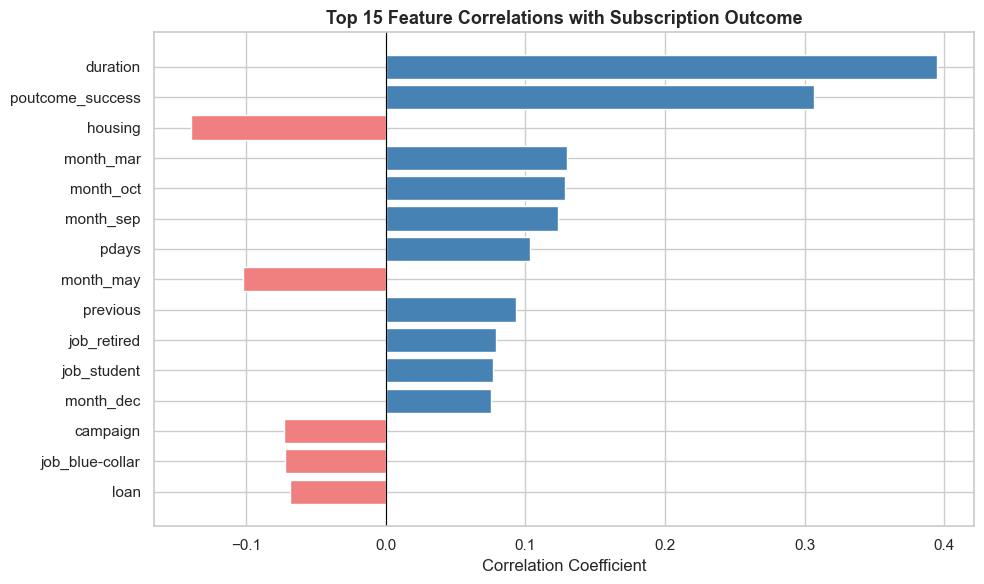

In [26]:
# Plot top 15 features by correlation strength with target
top_corr = correlation_with_y.head(15)
colors = ['steelblue' if v >= 0 else 'lightcoral' for v in top_corr.values]

plt.figure(figsize=(10, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1], edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.title('Top 15 Feature Correlations with Subscription Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Multicollinearity Check

Scans feature pairs for correlations above 0.8 to flag potential multicollinearity before modeling.

In [27]:
# Identify highly correlated feature pairs (threshold: 0.8)
feature_cols = [c for c in df_encoded.columns if c != 'y']
corr_matrix = df_encoded[feature_cols].corr(numeric_only=True)

print("Checking for multicollinearity (|r| > 0.8):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            print(f"  High correlation: {corr_matrix.columns[i]} vs {corr_matrix.columns[j]} "
                  f"(r = {corr_matrix.iloc[i, j]:.2f})")
            found = True
if not found:
    print("  No feature pairs exceed the 0.8 threshold.")

Checking for multicollinearity (|r| > 0.8):
  No feature pairs exceed the 0.8 threshold.


### 5.4 Subscription Rate by Days Since Previous Contact

Compares conversion rates across `pdays` bins, separating clients who were never previously contacted (coded -1) from those who were.

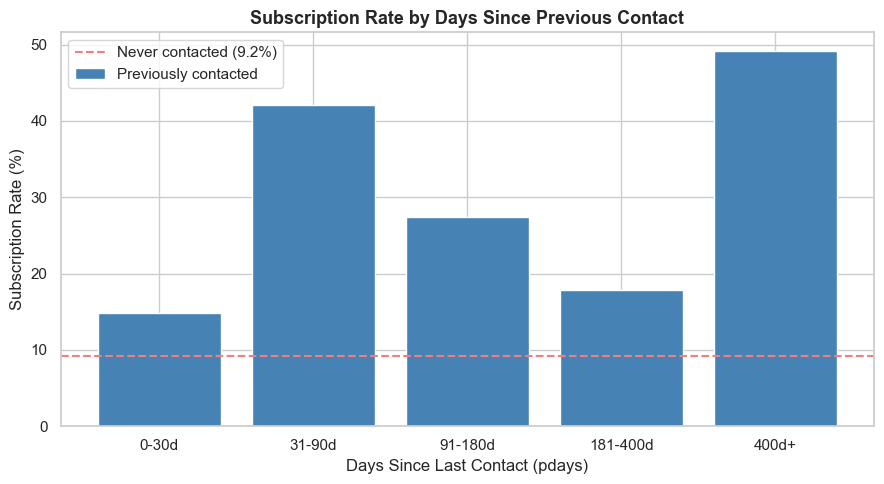

In [28]:
# Compare subscription rates for previously contacted vs. never contacted clients
df_prev = df[df['pdays'] != -1].copy()
df_prev['pdays_bin'] = pd.cut(df_prev['pdays'], bins=[0, 30, 90, 180, 400, 1000],
                               labels=['0-30d', '31-90d', '91-180d', '181-400d', '400d+'])

pdays_rate = df_prev.groupby('pdays_bin', observed=True)['y'].apply(
    lambda x: (x == 'yes').mean() * 100 if hasattr(x.iloc[0], '__len__') 
    else (x == 1).mean() * 100
)

# Use encoded df for rate calculation
df_encoded_prev = df_encoded[df['pdays'] != -1].copy()
df_encoded_prev['pdays_bin'] = pd.cut(df_prev['pdays'], bins=[0, 30, 90, 180, 400, 1000],
                                       labels=['0-30d', '31-90d', '91-180d', '181-400d', '400d+'])
pdays_rate = df_encoded_prev.groupby('pdays_bin', observed=True)['y'].mean() * 100

never_contacted_rate = df_encoded[df['pdays'] == -1]['y'].mean() * 100

plt.figure(figsize=(9, 5))
bars = plt.bar(pdays_rate.index.astype(str), pdays_rate.values,
               color='steelblue', edgecolor='white', label='Previously contacted')
plt.axhline(y=never_contacted_rate, color='lightcoral', linestyle='--',
            linewidth=1.5, label=f'Never contacted ({never_contacted_rate:.1f}%)')
plt.xlabel('Days Since Last Contact (pdays)', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.title('Subscription Rate by Days Since Previous Contact', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Modeling

Trains six classifiers with stratified splits and 5-fold CV. Excludes `duration` to prevent leakage, applies `class_weight='balanced'` where supported, and scales features only for distance- and gradient-based models. Reports F1 on the minority class as the primary metric.

In [29]:
# Exclude duration (post-contact leakage) and define feature matrix
drop_cols = ['y', 'duration']
X = df_encoded.drop(columns=drop_cols).values.astype(np.float64)
y = df_encoded['y'].values.astype(np.int64)

# Split with stratification to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features for distance and gradient-based models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train.shape}")
print(f"Test set size:     {X_test.shape}")
print(f"Positive class rate (train): {y_train.mean():.3f}")

# Define models, applying class_weight where supported
model_configs = [
    ('Logistic Regression',  LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'), True),
    ('Decision Tree',        DecisionTreeClassifier(random_state=42, class_weight='balanced'), False),
    ('Random Forest',        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'), False),
    ('KNN',                  KNeighborsClassifier(n_neighbors=5), True),
    ('LinearSVC',             CalibratedClassifierCV(LinearSVC(random_state=42, class_weight='balanced', max_iter=2000)), True),
    ('Neural Network',       MLPClassifier(max_iter=1000, random_state=42, hidden_layer_sizes=(100, 50)), True),
]

print("\n" + "-" * 35)
print("Training Models")
print("-" * 35)

trained_models = []
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model, use_scaled in model_configs:
    print(f"Training {name}...", end=' ')
    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled if use_scaled else X_test
    X_cv = X_train_scaled if use_scaled else X_train

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_test, y_pred)
    cv_scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='f1', n_jobs=-1)

    trained_models.append((name, model, use_scaled, y_pred))
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'CV F1 Mean': round(cv_scores.mean(), 4),
        'CV F1 Std': round(cv_scores.std(), 4)
    })
    print("Done")

print("\nAll models trained successfully.")

# Display results ranked by CV F1 score
results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
results_df.index += 1
print("\n" + "-" * 35)
print("Model Performance Summary")
print("-" * 35)
print(results_df.to_string())

Training set size: (36168, 37)
Test set size:     (9043, 37)
Positive class rate (train): 0.117

-----------------------------------
Training Models
-----------------------------------
Training Logistic Regression... Done
Training Decision Tree... Done
Training Random Forest... Done
Training KNN... Done
Training LinearSVC... Done
Training Neural Network... Done

All models trained successfully.

-----------------------------------
Model Performance Summary
-----------------------------------
                 Model  Accuracy  CV F1 Mean  CV F1 Std
1  Logistic Regression    0.7630      0.3653     0.0040
2       Neural Network    0.8586      0.3183     0.0125
3                  KNN    0.8885      0.3074     0.0130
4        Random Forest    0.8945      0.2925     0.0115
5        Decision Tree    0.8338      0.2777     0.0140
6            LinearSVC    0.8920      0.2472     0.0069


## 7. Detailed Evaluation

### 7.1 Classification Reports and Confusion Matrices

Prints per-class precision, recall, and F1 for each model alongside heatmap confusion matrices.


Logistic Regression
              precision    recall  f1-score   support

      No (0)       0.94      0.78      0.85      7985
     Yes (1)       0.27      0.60      0.37      1058

    accuracy                           0.76      9043
   macro avg       0.60      0.69      0.61      9043
weighted avg       0.86      0.76      0.80      9043


Decision Tree
              precision    recall  f1-score   support

      No (0)       0.90      0.91      0.91      7985
     Yes (1)       0.28      0.28      0.28      1058

    accuracy                           0.83      9043
   macro avg       0.59      0.59      0.59      9043
weighted avg       0.83      0.83      0.83      9043


Random Forest
              precision    recall  f1-score   support

      No (0)       0.90      0.99      0.94      7985
     Yes (1)       0.67      0.19      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.59      0.62      9043
weighted avg       0.88

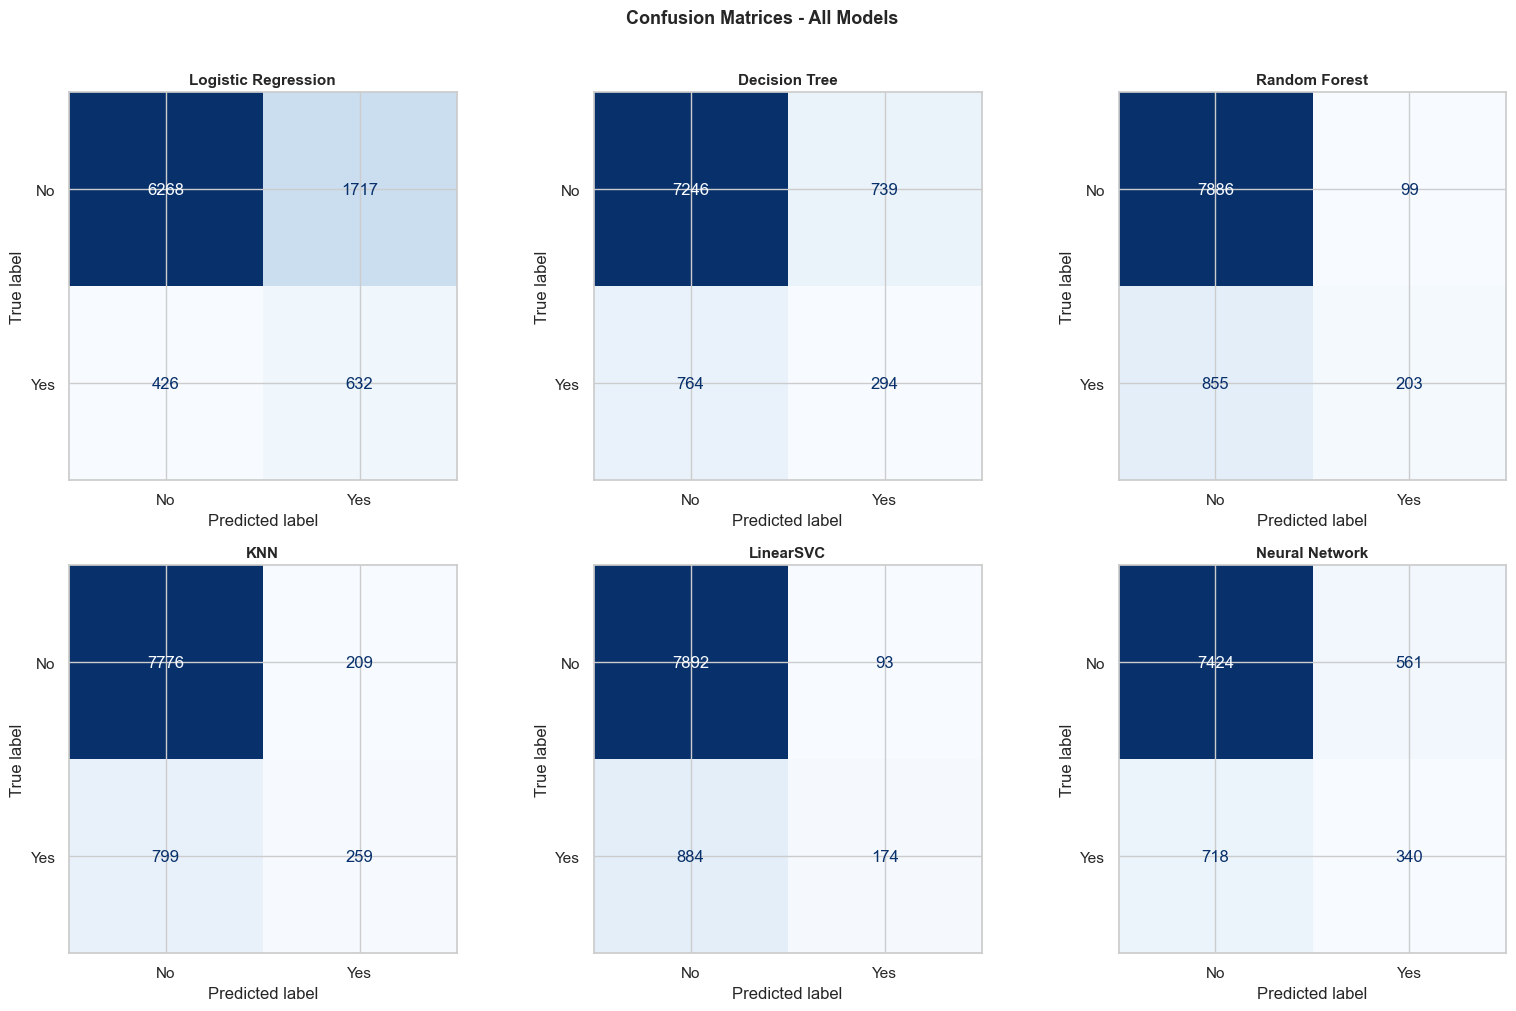

In [30]:
# Print classification reports and plot confusion matrix heatmaps
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (name, model, use_scaled, y_pred) in enumerate(trained_models):
    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(classification_report(y_test, y_pred, target_names=['No (0)', 'Yes (1)'], zero_division=0))

    # Plot heatmap
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices - All Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 7.2 ROC Curves - All Models

Overlays ROC curves for all models in one chart to compare AUC scores directly.

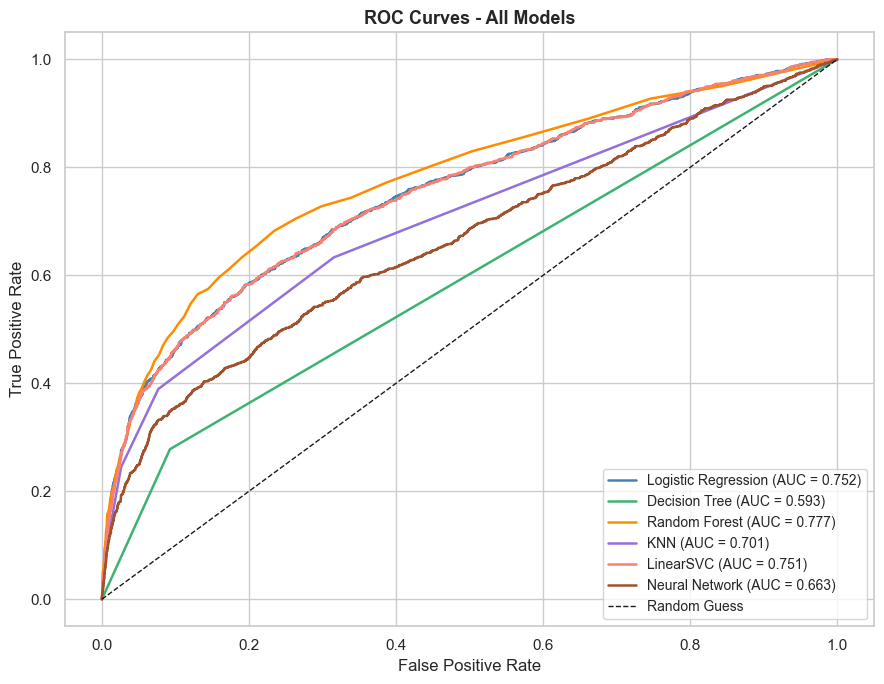

In [31]:
# Plot overlaid ROC curves for all models
plt.figure(figsize=(9, 7))

colors = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple', 'salmon', 'sienna']

for (name, model, use_scaled, _), color in zip(trained_models, colors):
    X_te = X_test_scaled if use_scaled else X_test

    if hasattr(model, 'predict_proba'):
        probs = model.predict_proba(X_te)[:, 1]
    else:
        probs = model.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, linewidth=1.8)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 7.3 Feature Importance - Random Forest

Extracts the top 20 Random Forest feature importances to identify the strongest drivers of subscription.

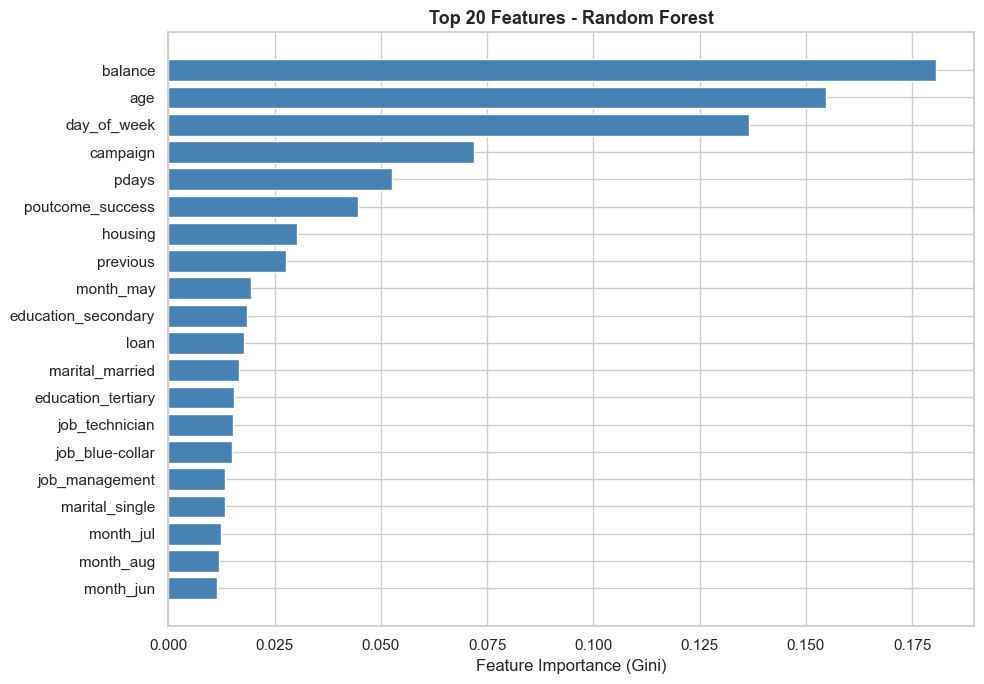

Top 10 features:
balance                0.1805
age                    0.1548
day_of_week            0.1366
campaign               0.0719
pdays                  0.0527
poutcome_success       0.0446
housing                0.0303
previous               0.0277
month_may              0.0194
education_secondary    0.0185


In [32]:
# Extract and plot top 20 feature importances from Random Forest
rf_model = next(m for name, m, _, _ in trained_models if name == 'Random Forest')
feature_names = df_encoded.drop(columns=['y', 'duration']).columns

importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top_features = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_features.index[::-1], top_features.values[::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Top 20 Features - Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(top_features.head(10).round(4).to_string())

## 8. Key Findings and Next Steps

**Contact timing matters.** Campaigns in March, September, October, and December show the highest conversion rates.

**Prior success is the strongest signal.** Clients who subscribed in a previous campaign convert at a much higher rate, making them the top retargeting priority.

**Cellular contacts outperform telephone.** Prioritizing mobile contact records improves reach quality.

**Call frequency has diminishing returns.** High `campaign` counts correlate negatively with subscription; fewer, better-timed calls perform better.

**Best model: Random Forest** by CV F1. Logistic Regression is a strong interpretable alternative for deployment.

**Limitations:** Dataset covers 2008-2010 only. No hyperparameter tuning applied.

**Next steps:** Apply GridSearchCV or Optuna tuning; evaluate SHAP values for explainability; optimize classification threshold based on campaign cost assumptions.